In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jainilcoder/online-payment-fraud-detection/onlinefraud.csv


In [2]:
# This path assumes the standard Kaggle input structure
df = pd.read_csv('/kaggle/input/datasets/jainilcoder/online-payment-fraud-detection/onlinefraud.csv')

# Display the first few rows to see what we're working with
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.shape

(6362620, 11)

In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
# Check the value counts for the 'isFraud' column
print(df['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


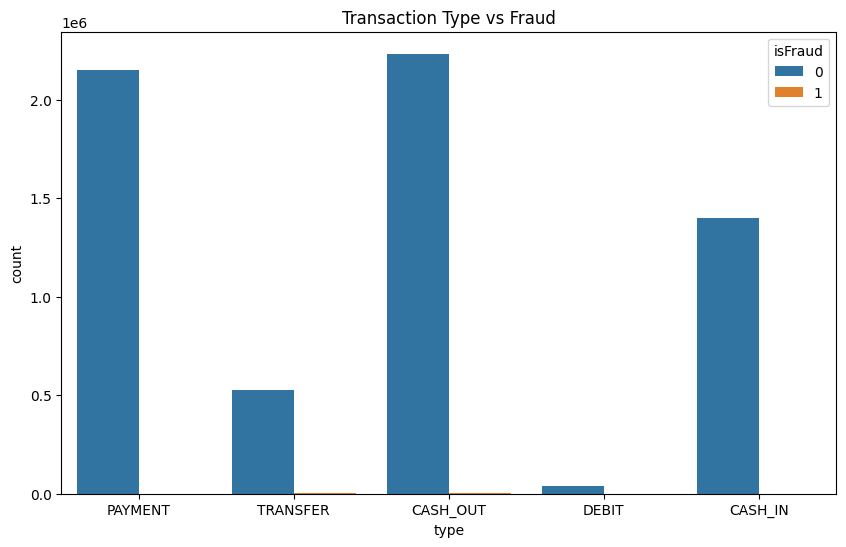

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check the distribution of transaction types
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='type', hue='isFraud')
plt.title('Transaction Type vs Fraud')
plt.show()

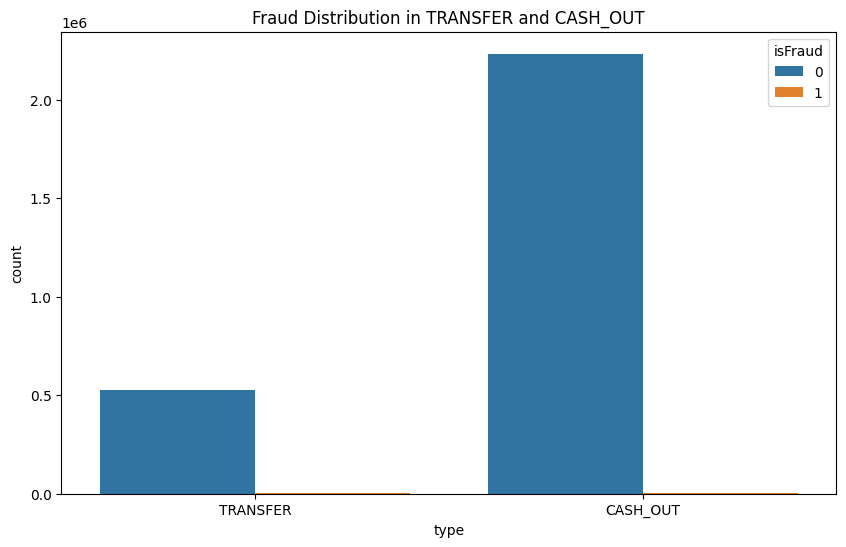

In [8]:
# Filter the data for only TRANSFER and CASH_OUT types
filtered_df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

# Plot the filtered data
plt.figure(figsize=(10, 6))
sns.countplot(data=filtered_df, x='type', hue='isFraud')
plt.title('Fraud Distribution in TRANSFER and CASH_OUT')
plt.show()

In [9]:
# 1. Drop the columns that are just unique identifiers and won't help the model
df = df.drop(['nameOrig', 'nameDest'], axis=1)

# 2. Convert the 'type' column into numerical values
# We map 'TRANSFER' to 0 and 'CASH_OUT' to 1 for the Decision Tree
df['type'] = df['type'].map({'TRANSFER': 0, 'CASH_OUT': 1})

# Since we only want to keep the rows that are now 0 or 1 (the ones we mapped),
# and drop the others (PAYMENT, DEBIT, CASH_IN) that we know aren't fraudulent:
df = df.dropna(subset=['type'])

# Check the first few rows to ensure the changes took effect
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,0.0,181.00,181.0,0.0,0.0,0.00,1,0
3,1,1.0,181.00,181.0,0.0,21182.0,0.00,1,0
15,1,1.0,229133.94,15325.0,0.0,5083.0,51513.44,0,0
19,1,0.0,215310.30,705.0,0.0,22425.0,0.00,0,0
24,1,0.0,311685.89,10835.0,0.0,6267.0,2719172.89,0,0


In [10]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')

In [11]:
# Check for null values in the 'type' column before dropping them
print(df['type'].isnull().sum())

0


In [12]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# 2. Split the data (80% for training, 20% for testing)
# We use random_state=42 so you get the same split every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 2216327 rows
Testing set size: 554082 rows


In [13]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the Decision Tree
# We set a random_state so your results are reproducible
model = DecisionTreeClassifier(random_state=42)

# 2. Train the model (This is the "learning" phase)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Use the trained model to make predictions on the test set
y_pred = model.predict(X_test)

# 2. Calculate the Accuracy Score
# This tells us the percentage of transactions correctly classified
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# 3. Create a Confusion Matrix
# This shows us exactly where the model got it right (or wrong)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Accuracy Score: 0.9993
Confusion Matrix:
[[552258    178]
 [   221   1425]]


In [15]:
import pandas as pd

# We'll use the same structure as before
columns = ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
           'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']

# THE TEST CASE:
# step=10, type=0 (TRANSFER), amount=25000.0, 
# oldbalanceOrg=25500.0, newbalanceOrig=500.0 (Drained mostly, but not zero)
# oldbalanceDest=100000.0, newbalanceDest=125000.0
subtle_fraud_df = pd.DataFrame([[10, 0, 25000.0, 25500.0, 500.0, 100000.0, 125000.0, 0]], columns=columns)

# Predict
prediction = model.predict(subtle_fraud_df)

if prediction[0] == 1:
    print("Result: The model was too smart! It caught this subtle fraud.")
else:
    print("Result: Success! You successfully bypassed the model with this subtle case. ✅")

Result: Success! You successfully bypassed the model with this subtle case. ✅
